In [6]:
import numpy as np
from utils import tf, analytic, lowpass

## Άσκηση — Διαμόρφωση DSB-SC (Double Sideband — Suppressed Carrier)

Στη **DSB-SC** πολλαπλασιάζουμε απευθείας το μήνυμα με το φέρον, **χωρίς** να προσθέτουμε συνιστώσα φέροντος:

$$ s(t) = A_c\,m(t)\,\cos(\omega_c t) = A_c A_m\cos(\omega_m t)\cos(\omega_c t) \tag{1}$$

Με την ταυτότητα γινομένου:

$$ s(t) = \tfrac{A_c A_m}{2}\cos((\omega_c\!-\!\omega_m)t) + \tfrac{A_c A_m}{2}\cos((\omega_c\!+\!\omega_m)t) \tag{2}$$

Το φάσμα έχει **μόνο** τις δύο πλευρικές στα $f_c\pm f_m$ — **καμία** γραμμή φέροντος. Το εύρος ζώνης παραμένει $W_B=2f_m$, όμως **όλη** η ισχύς μεταφέρει πληροφορία (πλήρης αποδοτικότητα).

**Αποδιαμόρφωση — σύγχρονη (coherent) ανίχνευση**: Ο δέκτης πρέπει να διαθέτει τοπικό ταλαντωτή **ίδιας συχνότητας και φάσης** με το φέρον. Πολλαπλασιάζοντας ξανά με $\cos(\omega_c t)$:

$$ v(t)=s(t)\cos(\omega_c t)=A_c m(t)\cos^2(\omega_c t) = \tfrac{A_c}{2}m(t) + \tfrac{A_c}{2}m(t)\cos(2\omega_c t) \tag{3}$$

Ένα **χαμηλοπερατό** φίλτρο απορρίπτει τον όρο στη συχνότητα $2\omega_c$ και αφήνει τον όρο $\tfrac{A_c}{2}m(t)$. 

Προσέξτε: ο **ανιχνευτής περιβάλλουσας αποτυγχάνει** εδώ, γιατί η περιβάλλουσα $A_c|m(t)|$ είναι ανορθωμένη (η πληροφορία προσήμου/φάσης χάνεται).

Σε όσα ακολουθούν, απεικονίζουμε μόνο τα φάσματα στο θετικό ημιάξονα των συχνοτήτων.

### i. Μήνυμα και φέρον

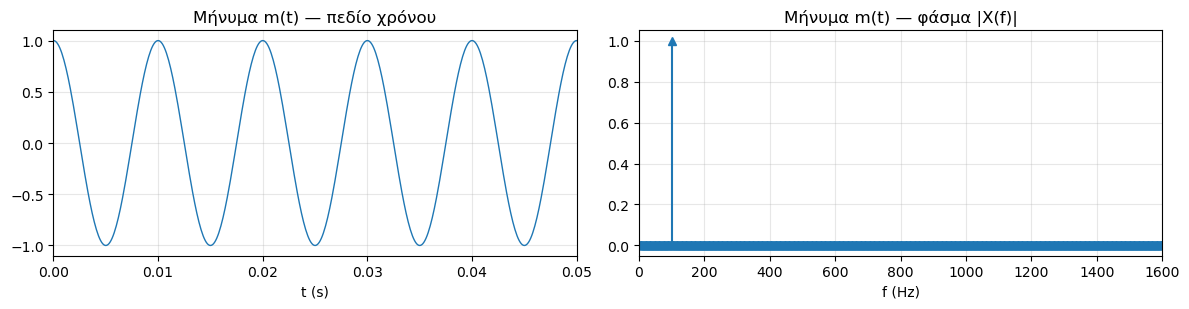

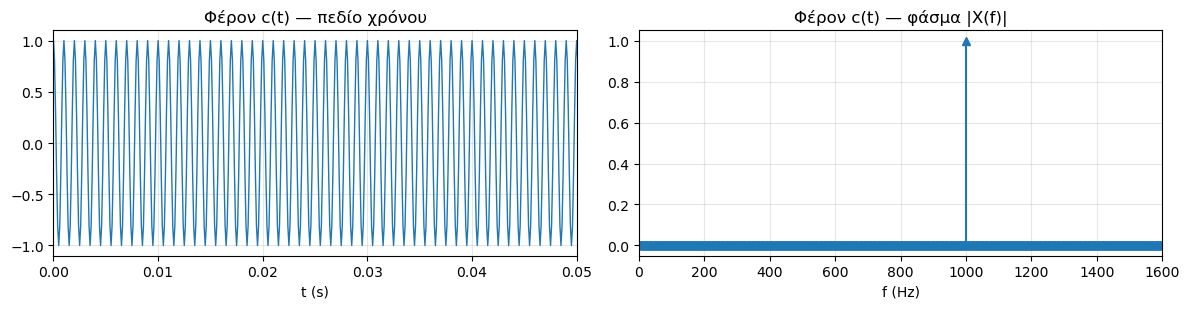

In [7]:
# ----- Παράμετροι (κοινές) -----
fs = 10000          # συχνότητα δειγματοληψίας (Hz)
N  = 4000           # πλήθος δειγμάτων (0.4 s)
t  = np.arange(N)/fs
fm = 100            # συχνότητα μηνύματος (Hz)
fc = 1000           # συχνότητα φέροντος (Hz)
Am = 1.0            # πλάτος μηνύματος
Ac = 1.0            # πλάτος φέροντος
wm = 2*np.pi*fm
wc = 2*np.pi*fc

m = Am*np.cos(wm*t)         # μήνυμα (ημιτονοειδές)
carrier = Ac*np.cos(wc*t)   # φέρον

tf(m, fs, 'Μήνυμα m(t)')
tf(carrier, fs, 'Φέρον c(t)')

### ii. Παραγωγή του σήματος DSB-SC

Υλοποιήστε απευθείας τη Σχέση (1).

**Διαμόρφωση** — στο φάσμα λείπει η γραμμή του φέροντος (1000 Hz)· υπάρχουν μόνο 900/1100 Hz.

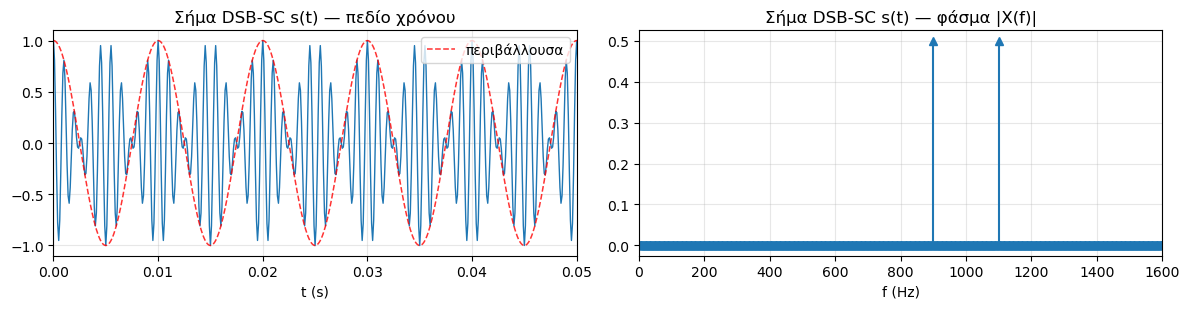

In [8]:
s = Ac * m * np.cos(wc*t) # INSERT CODE HERE
env_theory = Ac*m           # 'περιβάλλουσα' που αλλάζει πρόσημο

tf(s, fs, 'Σήμα DSB-SC s(t)', ref=env_theory)

### iii. Γιατί αποτυγχάνει ο ανιχνευτής περιβάλλουσας

Σε αντίθεση με τη διαμόρφωση ΑΜ, η περιβάλλουσα $|s(t)|$ δίνει τον όρο $A_c|m(t)|$, ο οποίος αποτελεί ένα ανορθωμένο μήνυμα διπλάσιας συχνότητας, στις στιγμές αλλαγής προσήμου του $m(t)$ εμφανίζονται **αναστροφές φάσης** $180^\circ$. Ας το δούμε:

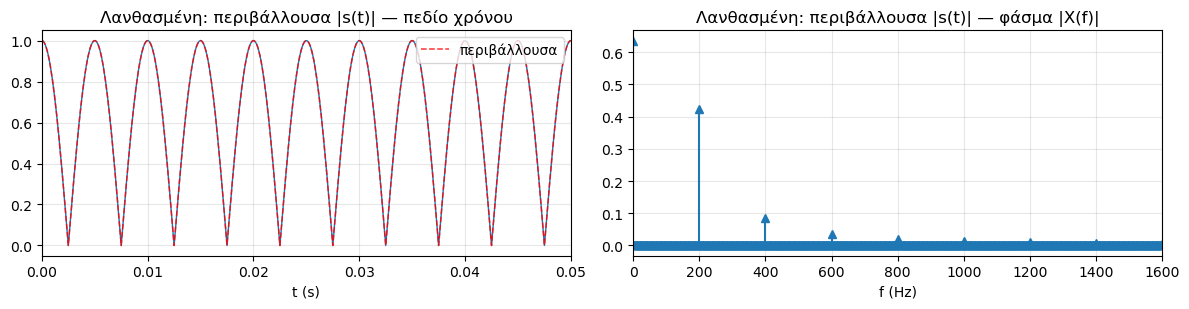

In [9]:
env_bad = np.abs(analytic(s))

tf(env_bad, fs, 'Λανθασμένη: περιβάλλουσα |s(t)|', ref=np.abs(Ac*m))

### iv. Σύγχρονη (coherent) αποδιαμόρφωση

Για να μπορέσουμε να ανακτήσουμε το μήνυμα, πολλαπλασιάζουμε με το τοπικό φέρον και φιλτράρουμε με ένα χαμηλοπερατό φίλτρο (Σχέση 3).

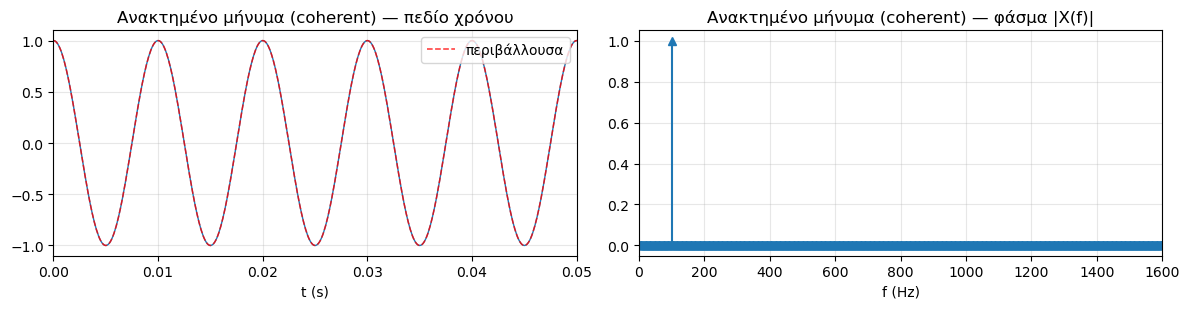

Το μέγιστο σφάλμα ανάκτησης: 1.287e-13


In [ ]:
v = s * np.cos(wc*t)                 # INSERT CODE HEREE
rec = lowpass(v, 1.5*fm, fs)         # INSERT CODE HERE - βαθυπερατό (cutoff μεταξύ fm και fc)
rec = rec / (Ac/2)                   # κανονικοποίηση -> m(t)

tf(rec, fs, 'Ανακτημένο μήνυμα (coherent)', ref=m)

sl = slice(200, N-200)
print(f'Το μέγιστο σφάλμα ανάκτησης ισούται με: {np.max(np.abs(rec[sl]-m[sl])):.3e}')

### Παρατηρήσεις

Η καταστολή του φέροντος φαίνεται καθαρά στο φάσμα: μόνο οι δύο πλευρικές στα $900$ και $1100$ Hz. Στο πεδίο του χρόνου η «περιβάλλουσα» του DSB-SC ακολουθεί το $A_c m(t)$ **αλλάζοντας πρόσημο**, γι' αυτό ο ανιχνευτής περιβάλλουσας παράγει το ανορθωμένο $A_c|m(t)|$, όπως είδαμε νωρίτερα. Αντίθετα, η **σύγχρονη ανίχνευση** ανακτά πλήρως το μήνυμα, με το κόστος ότι ο δέκτης χρειάζεται τοπικό ταλαντωτή κλειδωμένο σε συχνότητα και φάση με το φέρον (εδώ, βολικά θέσαμε τη φάση ίση με το μηδέν). Το DSB-SC είναι αποδοτικό σε επίπεδο ισχύος αλλά καταλαμβάνει το ίδιο εύρος ζώνης ($2f_m$) με τη διαμόρφωση AM.

---
---